# 12 · Use the organizer

**Step 2.** One line reopens everything `11` built. From here the organizer is
the only thing the work touches.

Six parts, in the order a session actually goes:

| | |
|---|---|
| **A** | load it, look at it, carve out the samples you care about |
| **B** | load data — all of it, or one frame at a time |
| **C** | visualise — the quick call, or your own figure from B |
| **D** | fit one, check it, *then* batch the same parameters |
| **E** | compare samples: ids → table → plot |
| **F** | reload, and go round again |

The through-line is that **nothing is a dead end**. Every quick call has a
lower-level one underneath it that hands you the arrays, because the moment an
analysis is interesting it stops fitting whatever the convenience function
assumed.

---
# A · Load the organizer and look at it

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from NanoOrganizer import Organizer
from NanoOrganizer.demo import demo_root

LAB = demo_root("Lab")
org = Organizer(LAB / "lab.json")
org

<Organizer 'lab demo': 7 samples, all — /home/yuzhang/Repos/OrgDemo/Lab/lab.json>

`describe()` is the first cell of a session: how many samples, what was done to
them, which techniques are present, what has been analysed, and how much of it
is readable *here*. No data is touched.

In [2]:
org.describe();

lab demo  (/home/yuzhang/Repos/OrgDemo/Lab/lab.json)
  samples       7
                S01, S02, S03, S04, S05, S06, S07
  stages        synthesis (7)
  Curves (1D)   uvvis, waxs1d
  Images & Maps (2D) tem
  measurements  18 (18 readable here, 0 not mounted)


In [3]:
# The same thing as a dict, when you want to branch on it rather than read it.
info = org.overview()
{k: info[k] for k in ("n_samples", "stages", "modalities", "analyses")}

{'n_samples': 7,
 'stages': {'synthesis': 7},
 'modalities': {'curve': ['uvvis', 'waxs1d'], 'image': ['tem']},
 'analyses': {}}

## The structure of the file itself

`tree()` walks the organizer one layer at a time — **structure, not data**. It
shows the live session, not the last save, which matters: walking the file on
disk would quietly show the state before your last twenty links and look
entirely correct.

In [4]:
print(org.tree(depth=2, limit=5))

📄 lab.json  23.0 KB
├── 🔑 project  7 keys
│   ├── · name  str = lab demo
│   ├── · description  str = 
│   ├── 📋 path_aliases  1 items of dict
│   ├── 📋 extra_roots  empty
│   ├── 📋 metadata_sources  empty
│   └── … +2 more  raise the per-layer limit to see them
└── 📋 samples  7 items of dict
    ├── 🔑 0  7 keys
    ├── 🔑 1  7 keys
    ├── 🔑 2  7 keys
    ├── 🔑 3  7 keys
    ├── 🔑 4  7 keys
    └── … +2 more  raise the per-layer limit to see them


In [5]:
# Descend into one sample's record. The address after :: is a path inside
# the document, exactly as it is for an HDF5 group or a metadata module.
print(org.tree(address="samples/0", depth=2, limit=6))

🔑 0
├── · sample_id  str = S01
├── 🔑 stages  1 keys
│   └── 🔑 synthesis  12 keys
├── 📋 measurements  3 items of dict
│   ├── 🔑 0  11 keys
│   ├── 🔑 1  11 keys
│   └── 🔑 2  11 keys
├── 🔑 derived  0 keys
├── 📋 tags  empty
├── · notes  str = 
└── … +1 more  raise the per-layer limit to see them


## Which samples are there

`catalog()` is the sample × technique matrix. The gaps are the point: a
measurement matrix is always sparse, and seeing which comparisons exist beats
discovering halfway through that the argument rests on a sample nobody
measured.

In [6]:
org.catalog()

,uvvis,tem,waxs1d
sample_id,,,
S01,True,True,True
S02,True,True,True
S03,True,True,True
S04,True,True,True
S05,True,True,True
S06,True,True,True
S07,False,False,False


In [7]:
# ids() answers a question without committing to it; filter() commits.
print("all:    ", org.ids())
print("hot:    ", org.ids("`synthesis.conditions.temperature_C` >= 90"))
print("basket: ", org.basket, "(unchanged)")

all:     ['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07']
hot:     ['S04', 'S05', 'S06', 'S07']
basket:  [] (unchanged)


## Carving out a sub-organizer

Two ways, and they compose: an explicit list when you know which samples, a
query when you know the condition.

A subset is a **deep copy**, not a view — so analysing it cannot write derived
values back into the parent by accident, which is the one thing a shared view
would get wrong. Path aliases come along, so the data still resolves. **Nothing
is written** until you call `save()`.

In [8]:
# By hand.
plate = org.subset(["S01", "S03", "S05"], name="odd")
print(plate, "->", plate.project.sample_ids())

# By filter.
hot = org.subset(query="`synthesis.conditions.temperature_C` >= 90", name="hot")
print(hot, "->", hot.project.sample_ids())

print("parent untouched:", org.project.sample_ids())
print("written to disk? ", hot.path.exists(), "—", hot.path.name)

<Organizer 'odd': 3 samples, all — /home/yuzhang/Repos/OrgDemo/Lab/lab__odd.json> -> ['S01', 'S03', 'S05']
<Organizer 'hot': 4 samples, all — /home/yuzhang/Repos/OrgDemo/Lab/lab__hot.json> -> ['S04', 'S05', 'S06', 'S07']
parent untouched: ['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07']
written to disk?  False — lab__hot.json


---
# B · Load data

Two questions, two answers.

**All of it**, when it is small enough that arguing costs more than reading:

```python
x, Y, info = org.data("S01", "uvvis")      # (n_frames, n_points)
array, info = org.data("S01", "tem", frame=1)
```

**One frame at a time**, when it is not. `lazy=True` resolves the file list up
front — so `len()`, the names and the per-frame table are available
immediately — and opens a file only when a frame is actually indexed.

That is the difference between looking at the third of four hundred
micrographs and reading twelve gigabytes to do it.

In [9]:
x, Y, info = org.data("S01", "uvvis")
print("eager:", x.shape, Y.shape, "|", info["source"])

image, meta = org.data("S01", "tem", frame=1)
print("eager:", image.shape, "|", meta["file"], "|", meta["nm_per_pixel"], "nm/px")

eager: (401,) (14, 401) | 14 files
eager: (320, 320) | img_02.tif | 0.5 nm/px


In [10]:
frames = org.data("S01", "tem", lazy=True)
print(frames)
print("length known without opening anything:", len(frames))
print("names:", frames.names)

<LazyFrames S01:tem:characterization image: 3 files, unread>
length known without opening anything: 3
names: ['img_01.tif', 'img_02.tif', 'img_03.tif']


In [11]:
# One file opened, here and nowhere else.
array, meta = frames[1]
print("frame 1:", array.shape, meta["file"])

# Iterating stays one-at-a-time. It is a sequence, not a generator, so this
# works twice and supports len() and [i] — all three of which you will want.
means = [frame.mean() for frame, _ in frames]
print("per-frame mean:", np.round(means, 1))

frame 1: (320, 320) img_02.tif
per-frame mean: [192.  191.7 191.8]


In [12]:
# And when you do want it all, you ask.
stack, meta = frames.load()
print("stacked:", stack.shape, "|", meta["source"])

stacked: (3, 320, 320) | stacked 3 frames


A single file holding a 3D volume is **memory-mapped**: its frames are the
planes, and indexing one costs one plane rather than the whole tomogram. The
lab demo has no tomography, so here is the shape of it on a small array.

In [13]:
scratch = LAB / "scratch_tomo.npy"
np.save(scratch, np.random.default_rng(0).random((64, 48, 48)))

tomo_org = Organizer(LAB / "scratch.json")
tomo_org.link("T01", "tomo", str(scratch))

planes = tomo_org.data("T01", "tomo", lazy=True)
print(planes, "| planes:", len(planes))
plane, meta = planes[32]
print("one plane:", plane.shape, "| index", meta["plane"])

<LazyFrames T01:tomo:characterization volume: 64 planes of scratch_tomo.npy, unread> | planes: 64
one plane: (48, 48) | index 32


## The layer below a measurement

`frames()` is the per-file table: one row each, with whatever the filename
admitted about when (`t_s`) and how hot (`T_c`) it was taken. That table is
what `t=` and `T=` select on, by **nearest** value — an acquisition clock never
lands on a round number.

In [14]:
org.frames("S01", "uvvis").head(4)

,index,file,path,t_s,T_c,batch,scan,kind
0,0,S01_t0000s.csv,/home/yuzhang/Repos/OrgDemo/Lab/RawData/spectr...,0.0,NaN,,-1,kinetic
1,1,S01_t0090s.csv,/home/yuzhang/Repos/OrgDemo/Lab/RawData/spectr...,90.0,NaN,,-1,kinetic
2,2,S01_t0180s.csv,/home/yuzhang/Repos/OrgDemo/Lab/RawData/spectr...,180.0,NaN,,-1,kinetic
3,3,S01_t0270s.csv,/home/yuzhang/Repos/OrgDemo/Lab/RawData/spectr...,270.0,NaN,,-1,kinetic


In [15]:
_, Y_first, info_first = org.data("S01", "uvvis", frame=0)
_, Y_600, info_600 = org.data("S01", "uvvis", t=600)
print(info_first["labels"], "->", info_600["labels"])

['S01_t0000s.csv'] -> ['S01_t0630s.csv']


---
# C · Visualise

The quick call dispatches on what the data *is* — the modality registry says
`uvvis` is a series (curves), `tem` an image, `waxs1d` a curve — so adding a
technique never adds a branch.

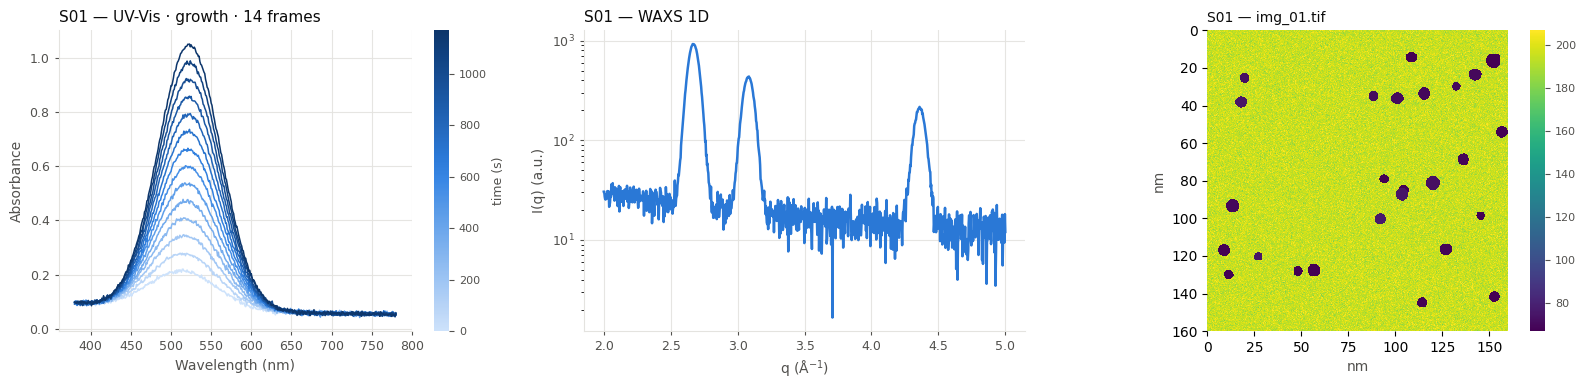

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
org.plot("S01", "uvvis", ax=axes[0])
org.plot("S01", "waxs1d", ax=axes[1])
org.plot("S01", "tem", ax=axes[2])
fig.tight_layout()

Two things happened without being asked. The growth series was **coloured along
one hue by acquisition time**, with a colour bar instead of a legend — the
times came from the filenames, and a legend of fourteen timestamps is not
readable. The micrograph is on **nanometre axes**, because the TIFF carried a
pixel calibration, so a distance read off it means something.

## Your own figure, from B

The quick call stops being enough about ten minutes into any real question.
When it does, take the arrays and draw it yourself — there is no third mode to
learn, because `plot` was only ever B plus matplotlib.

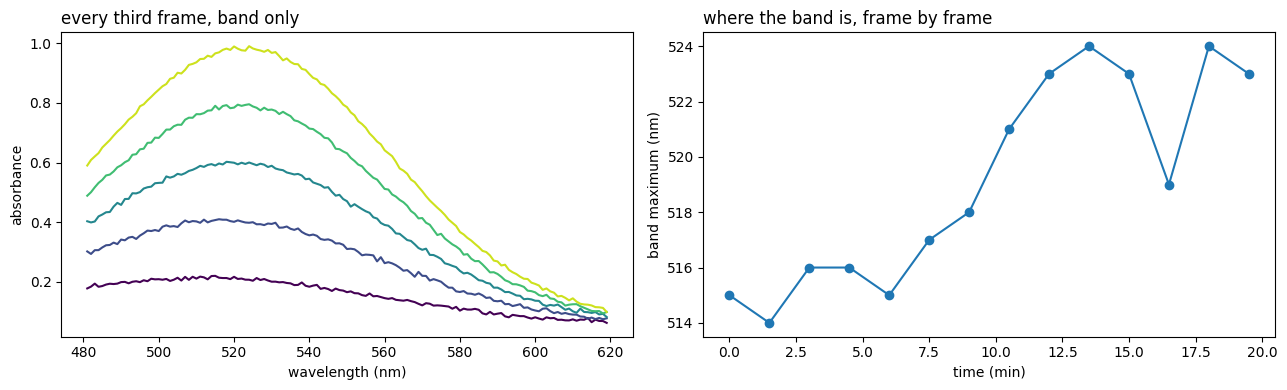

In [17]:
x, Y, info = org.data("S01", "uvvis")
times = np.asarray(info["t_s"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: the spectra, but only the band, and only every third frame.
band = (x > 480) & (x < 620)
for index in range(0, Y.shape[0], 3):
    axes[0].plot(x[band], Y[index][band],
                 color=plt.cm.viridis(times[index] / times.max()))
axes[0].set_xlabel("wavelength (nm)"); axes[0].set_ylabel("absorbance")
axes[0].set_title("every third frame, band only", loc="left")

# Right: something no built-in offers — the band maximum against time, with
# the growth curve it implies.
peak_nm = x[band][Y[:, band].argmax(axis=1)]
axes[1].plot(times / 60, peak_nm, "o-")
axes[1].set_xlabel("time (min)"); axes[1].set_ylabel("band maximum (nm)")
axes[1].set_title("where the band is, frame by frame", loc="left")

fig.tight_layout()

## Comparing samples

Three routes to the same figure. Use whichever matches what you already have.

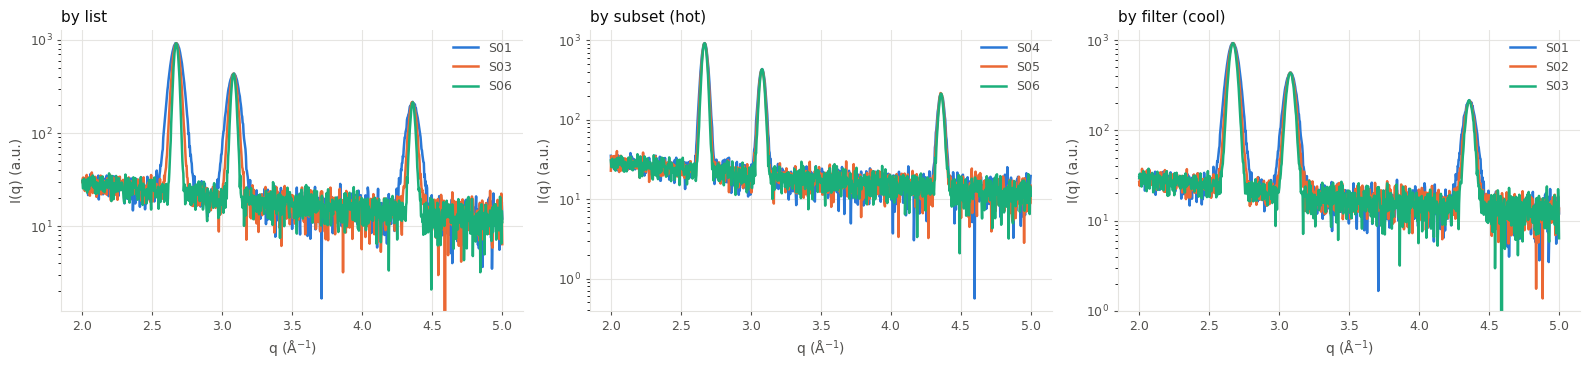

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))

# 1. An explicit list — no selection disturbed, nothing created.
org.overlay("waxs1d", sample_ids=["S01", "S03", "S06"], ax=axes[0],
            title="by list")

# 2. A sub-organizer from A.
hot.overlay("waxs1d", ax=axes[1], title="by subset (hot)")

# 3. The current selection.
org.filter("`synthesis.conditions.temperature_C` <= 80")
org.overlay("waxs1d", ax=axes[2], title="by filter (cool)")
org.clear()

fig.tight_layout()

---
# D · Fit one, check it, then batch

Three levels, and you can enter at any of them. The order matters: settling the
parameters on a sample you can **look at**, and only then spending them on the
whole set, is the same work as running the batch first and reading its R²
column afterwards — in the order that does not hide the mistake.

| | |
|---|---|
| `fit_peaks(x, y, …)` | the **kernel** — arrays in, result out. No files, no project. |
| `org.fit(sample, modality, …)` | finds the curve for you, runs the kernel, stores nothing |
| `org.batch(key, link=True, …)` | the whole selection, derived columns written, fits linked |

Start at the bottom when it works and at the top when it does not.

## The kernel: fitting arrays

`fit_peaks` takes two numpy arrays and nothing else. That is the point — when
a fit is misbehaving you want to change one number and look again, not
re-navigate a measurement, a resolver and a registry to get there.

It pairs with `plot_fit`, which also takes arrays, so the house style is
available to any `x, y, y_fit` you have from anywhere.

In [19]:
from NanoOrganizer.analysis import fit_peaks
from NanoOrganizer.viz.plots import plot_fit

x, Y, info = org.data("S01", "waxs1d")
print(x.shape, Y.shape, info["source"])

fit = fit_peaks(x, Y[0], n_peaks=1, x_range=(2.3, 3.0), background="linear")
fit

(900,) (1, 900) 1 files


<PeakFitResult 1 peak(s) at [2.67], R² = 0.9993>

params: {'baseline': 23.8208, 'baseline_slope': 2.7747, 'peak1_amplitude': 898.2519, 'peak1_center': 2.67, 'peak1_width': 0.0398}
errors: {'baseline': 0.99996, 'baseline_slope': 2.40533, 'peak1_amplitude': 1.90336, 'peak1_center': 0.0001, 'peak1_width': 0.0001}
used:   {'n_peaks': 1, 'shape': 'gaussian', 'background': 'linear', 'x_range': (2.300333704115684, 2.9977753058954395), 'n_points': 210}


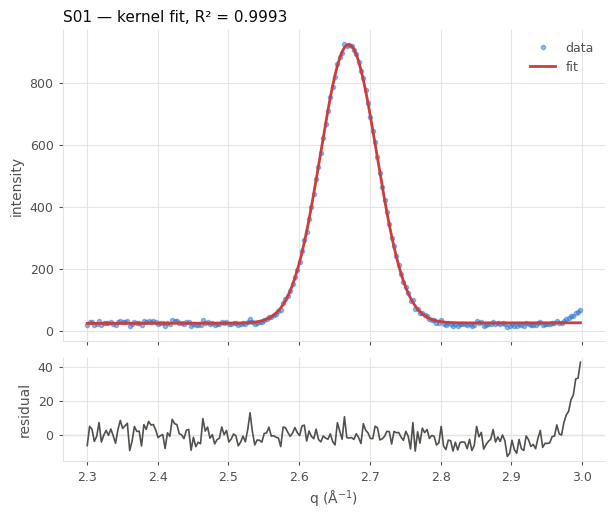

In [20]:
print("params:", {k: round(v, 4) for k, v in fit.params.items()})
print("errors:", {k: round(v, 5) for k, v in fit.errors.items()})
print("used:  ", fit.settings)

plot_fit(fit.x, fit.y, fit.y_fit, fit.residual,
         xlabel="q (Å$^{-1}$)", ylabel="intensity",
         title=f"S01 — kernel fit, R² = {fit.r2:.4f}");

Nothing in that cell knew about an organizer. The same two calls work on data
from a text file, a collaborator's email, or a simulation — which is the test
of whether the split is real.

Sweeping a parameter is now a loop over the kernel, not a loop over the
framework:

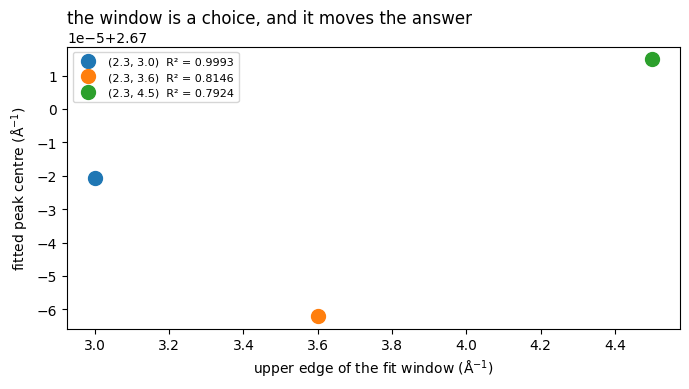

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
for window in [(2.3, 3.0), (2.3, 3.6), (2.3, 4.5)]:
    trial = fit_peaks(x, Y[0], n_peaks=1, x_range=window, background="linear")
    ax.plot(window[1], trial.params["peak1_center"], "o", ms=10,
            label=f"{window}  R² = {trial.r2:.4f}")

ax.set_xlabel("upper edge of the fit window (Å$^{-1}$)")
ax.set_ylabel("fitted peak centre (Å$^{-1}$)")
ax.set_title("the window is a choice, and it moves the answer", loc="left")
ax.legend(fontsize=8)
fig.tight_layout()

The widest window drags the centre and drops R² — it is pulling in the next
reflection. That is the kind of thing worth seeing *before* committing to a
batch, and it took three lines because the fit was a function of arrays.

## The wrapper: the same fit, found for you

In [22]:
params = dict(x_range=(2.3, 3.0), n_peaks=1, background="linear")

trial = org.fit("S01", "waxs1d", **params)
print(trial)
print("stored anything?", org["S01"].get_derived("waxs1d_peak1_center"))

<AnalysisResult peak_fit S01: baseline=23.82, baseline_slope=2.775, peak1_amplitude=898.3>
stored anything? None


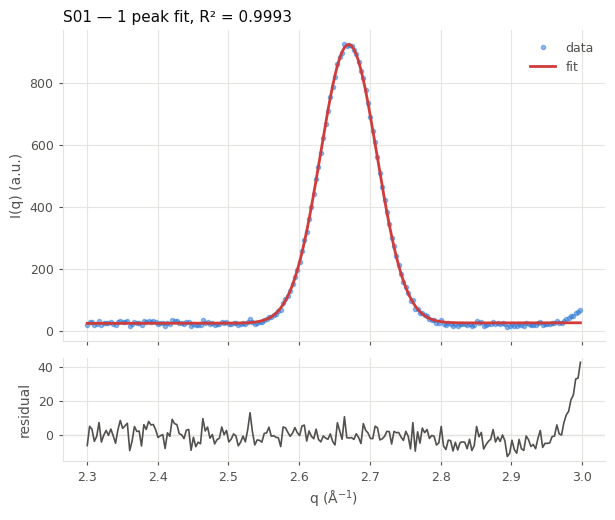

In [23]:
# show=True draws the fit over its data with the residuals beneath — which is
# where a bad fit shows. A fitted line over data is persuasive whatever it does.
trial, axes = org.fit("S01", "waxs1d", show=True, **params)

A deliberately bad window, to see what being wrong looks like. The residuals
stop being noise and start having shape.

R² = 0.7922  vs good: 0.9993


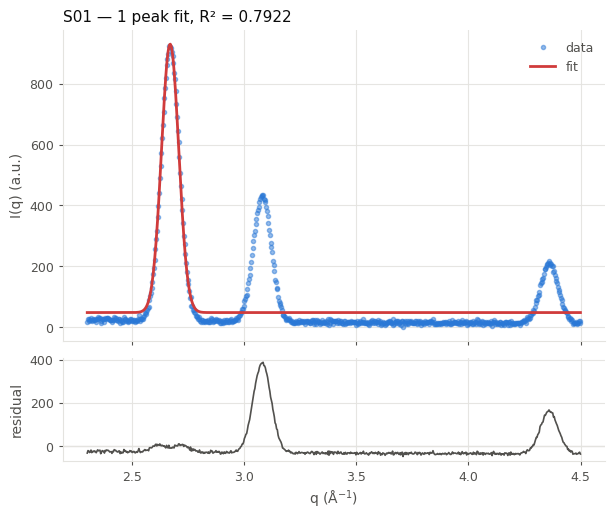

In [24]:
bad = org.fit("S01", "waxs1d", x_range=(2.3, 4.5), n_peaks=1,
              background="constant")
org.plot_fit(bad)
print("R² =", round(bad.values["fit_r2"], 4), " vs good:",
      round(trial.values["fit_r2"], 4))

Happy with the parameters — now spend them. `link=True` also saves each
result's **curves** beside the organizer and links the file onto its sample, so
the fits can be redrawn later without being recomputed.

In [25]:
org.batch("peak_fit", modality="waxs1d", link=True, **params)
org.batch("peak_fit", modality="uvvis", link=True,
          x_range=(450, 700), n_peaks=1, background="linear")

# Two peak fits per sample now — one per technique. They are two
# results, not one, so each is stored and addressed separately.
org.results()[["sample_id", "analysis", "modality", "ok", "fit_r2"]]

peak_fit: 6/6 succeeded, linked 6
peak_fit: 6/6 succeeded, linked 6


,sample_id,analysis,modality,ok,fit_r2
0,S01,peak_fit,waxs1d,True,0.999268
1,S01,peak_fit,uvvis,True,0.999857
2,S02,peak_fit,waxs1d,True,0.999707
3,S02,peak_fit,uvvis,True,0.999873
4,S03,peak_fit,waxs1d,True,0.999718
5,S03,peak_fit,uvvis,True,0.999877
6,S04,peak_fit,waxs1d,True,0.999504
7,S04,peak_fit,uvvis,True,0.999874
8,S05,peak_fit,waxs1d,True,0.999647
9,S05,peak_fit,uvvis,True,0.999861


In [26]:
print(org.save())

/home/yuzhang/Repos/OrgDemo/Lab/lab.json


---
# E · Compare samples

Ids → table → plot. Each step is a thing you can look at, which is the point:
a one-call comparison that disagrees with your expectation gives you nothing to
inspect.

In [27]:
# 1. The ids.
ids = org.ids("`synthesis.status` == 'done'")
print(ids)

# 2. The table. Derived names carry the modality they were fitted on, so
#    fitting two techniques cannot silently overwrite one result with the other.
truth = pd.read_csv(LAB / "Meta" / "truth.csv").set_index("sample_id")

FWHM_PER_SIGMA = 2.3548      # peak1_width is the Gaussian sigma, not the FWHM
table = org.table(sample_ids=ids)

check = pd.DataFrame({
    "temperature_C": table["synthesis.conditions.temperature_C"],
    "fitted_band_nm": table["derived.uvvis_peak1_center"],
    "waxs_fwhm_invA": table["derived.waxs1d_peak1_width"] * FWHM_PER_SIGMA,
}).join(truth[["true_band_nm", "true_diameter_nm"]]).dropna()

check.round(3)

['S01', 'S02', 'S03', 'S04', 'S05', 'S06']


,temperature_C,fitted_band_nm,waxs_fwhm_invA,true_band_nm,true_diameter_nm
sample_id,,,,,
S01,60.0,522.830,0.094,523.4,6.0
S02,72.5,525.717,0.075,526.4,7.6
S03,80.0,528.561,0.062,529.5,9.2
S04,90.0,531.477,0.052,532.5,10.8
S05,100.0,534.341,0.046,535.6,12.4
S06,110.0,537.309,0.040,538.6,14.0


plasmon band recovered to within 1.3 nm
Scherrer slope 0.561 (expect 0.565), intercept 0.00042 (expect ~0)


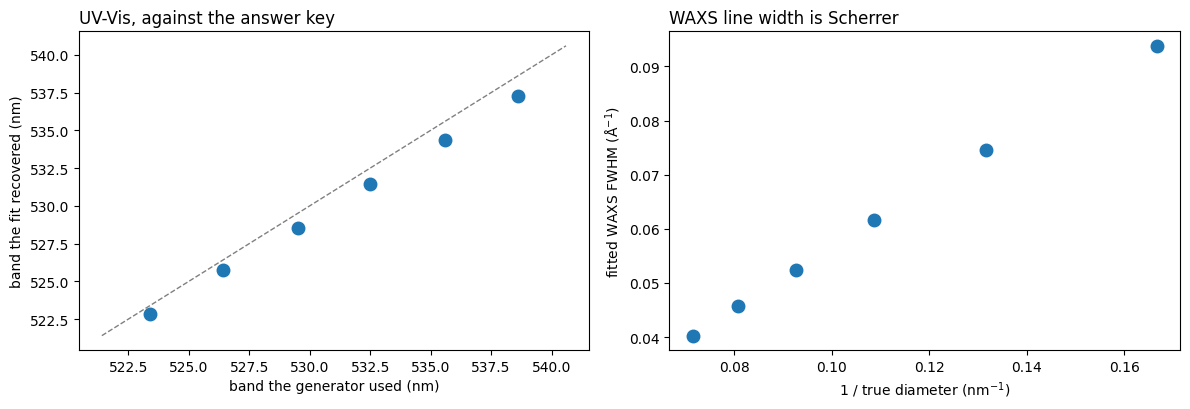

In [28]:
# 3. The plot.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(check["true_band_nm"], check["fitted_band_nm"], "o", ms=9)
lo, hi = check["true_band_nm"].min() - 2, check["true_band_nm"].max() + 2
axes[0].plot([lo, hi], [lo, hi], "--", lw=1, color="0.5")
axes[0].set_xlabel("band the generator used (nm)")
axes[0].set_ylabel("band the fit recovered (nm)")
axes[0].set_title("UV-Vis, against the answer key", loc="left")

# Scherrer: line width goes as 1/diameter — a straight line through the origin
# with slope 0.9 * 2*pi / 10.
inverse_d = 1.0 / check["true_diameter_nm"]
axes[1].plot(inverse_d, check["waxs_fwhm_invA"], "o", ms=9)
axes[1].set_xlabel("1 / true diameter (nm$^{-1}$)")
axes[1].set_ylabel("fitted WAXS FWHM (Å$^{-1}$)")
axes[1].set_title("WAXS line width is Scherrer", loc="left")

fig.tight_layout()

slope, intercept = np.polyfit(inverse_d, check["waxs_fwhm_invA"], 1)
worst = (check.fitted_band_nm - check.true_band_nm).abs().max()
print(f"plasmon band recovered to within {worst:.1f} nm")
print(f"Scherrer slope {slope:.3f} (expect {0.9 * 2 * np.pi / 10:.3f}), "
      f"intercept {intercept:.5f} (expect ~0)")

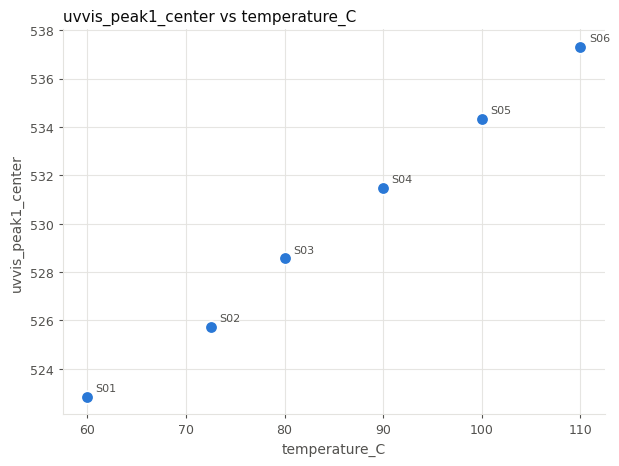

In [29]:
# Structure against property, straight off the table.
org.plot_compare("synthesis.conditions.temperature_C",
                 "derived.uvvis_peak1_center");

---
# F · Reload, and go round again

This is why linking the results was worth doing. Nothing is refitted — the
curves come off disk, and the figure is the one the analysis drew, independent
of whether the fitting code still behaves the same way.

In [30]:
later = Organizer(LAB / "lab.json")
later.describe();

lab demo  (/home/yuzhang/Repos/OrgDemo/Lab/lab.json)
  samples       7
                S01, S02, S03, S04, S05, S06, S07
  stages        synthesis (7)
  Curves (1D)   uvvis, waxs1d
  Images & Maps (2D) tem
  measurements  30 (30 readable here, 0 not mounted)
  stored fits   peak_fit (uvvis) (6), peak_fit (waxs1d) (6)
  derived       12: uvvis_baseline, uvvis_baseline_slope, uvvis_fit_r2, uvvis_peak1_amplitude …


peak_fit | ['residual', 'x', 'y', 'y_fit'] | S03:waxs1d:characterization


array([<Axes: title={'left': 'S03 — 1 peak fit, R² = 0.9997'}, ylabel='I(q) (a.u.)'>,
       <Axes: xlabel='q (Å$^{-1}$)', ylabel='residual'>], dtype=object)

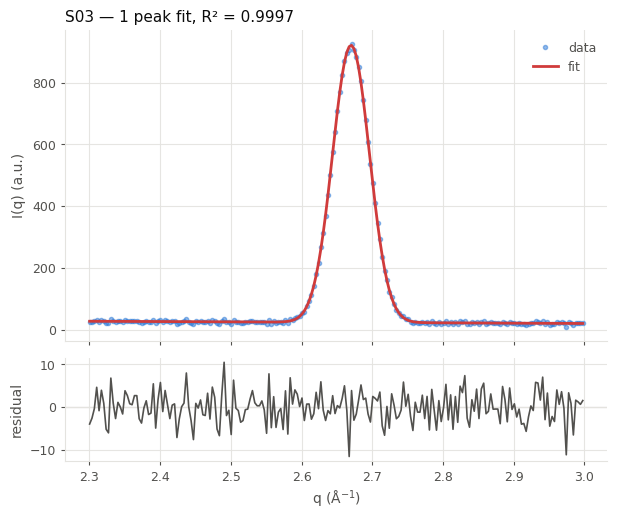

In [31]:
result = later.result("S03", "peak_fit", modality="waxs1d")
print(result.analysis, "|", sorted(result.curves), "|", result.measurement_id)

later.plot_result("S03", "peak_fit", modality="waxs1d")


In [32]:
# A stored fit sits on its sample as a measurement of modality `fit`, so it
# shows up in the catalog beside the techniques it came from.
print(later.catalog())

# S05 has two of them, so asking for "the fit" is ambiguous — and says so
# rather than picking one.
try:
    later.plot("S05", "fit")
except KeyError as exc:
    print("\n", exc)


           uvvis    tem  waxs1d    fit
sample_id                             
S01         True   True    True   True
S02         True   True    True   True
S03         True   True    True   True
S04         True   True    True   True
S05         True   True    True   True
S06         True   True    True   True
S07        False  False   False  False

 'S05 has 2 matching measurements: S05:fit:analysis-peak-fit-waxs1d, S05:fit:analysis-peak-fit-uvvis. Narrow with stage= or role=.'


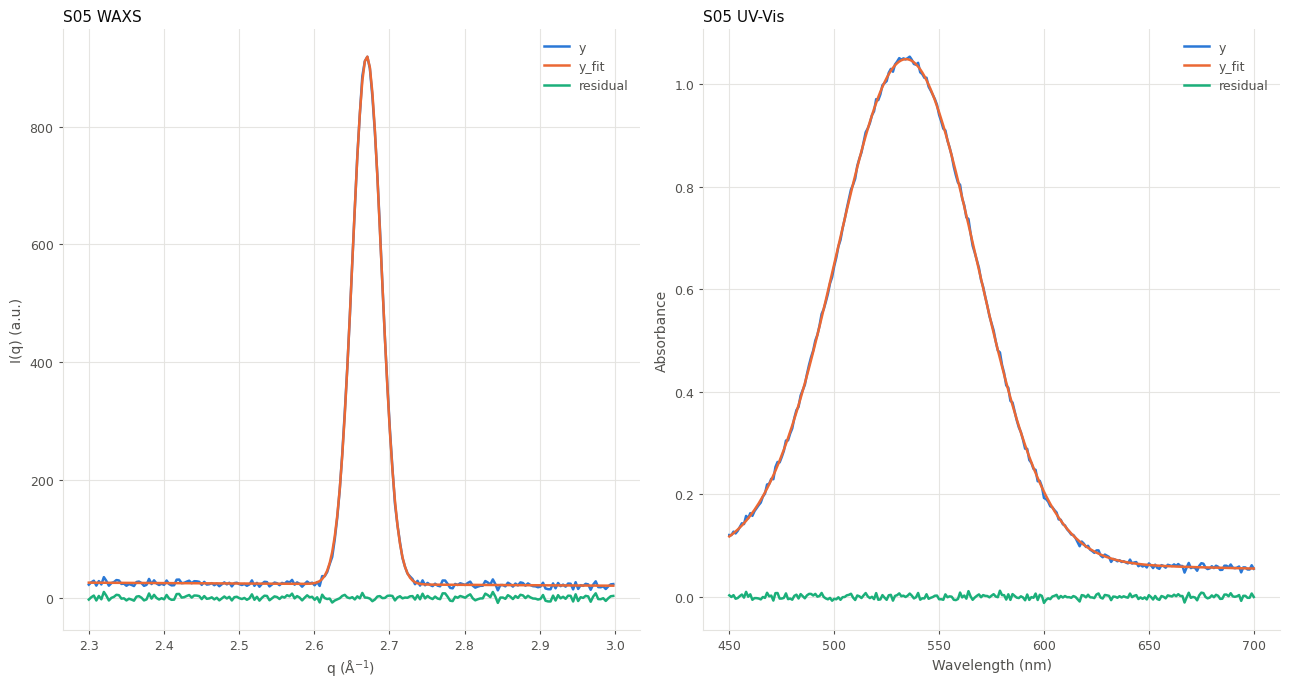

In [33]:
# Narrowed, either by the role the linker gave it or — more readably —
# through plot_result, which takes the analysis and the technique.
fig, axes = plt.subplots(1, 2, figsize=(13, 7))
later.plot_result("S05", "peak_fit", modality="waxs1d", ax=axes[0],
                  title="S05 WAXS")
later.plot_result("S05", "peak_fit", modality="uvvis", ax=axes[1],
                  title="S05 UV-Vis")
fig.tight_layout()


In [34]:
# Clean up the scratch tomogram this notebook made.
for path in (LAB / "scratch_tomo.npy", LAB / "scratch.json"):
    path.unlink(missing_ok=True)


---

## The whole surface, in one place

| | |
|---|---|
| **A** | `Organizer(path)` · `describe()` · `overview()` · `tree()` · `catalog()` · `ids()` · `filter()` · `subset()` |
| **B** | `data(s, m)` · `data(s, m, frame=/t=/T=)` · `data(s, m, lazy=True)` · `frames(s, m)` |
| **C** | `plot(s, m)` · `overlay(m, sample_ids=…)` · or your own, from B |
| **D** | `fit(s, m, show=True)` · `plot_fit(result)` · `batch(key, link=True)` |
| **E** | `ids()` → `table(sample_ids=…)` → `plot_compare()` |
| **F** | `Organizer(path)` · `results()` · `result(s, key, modality=…)` · `plot_result()` |

## The same object, with buttons

```bash
streamlit run NanoOrganizer/web_app/Home.py       # or: viz
```

**📁 Project → Open project** takes the path to `lab.json`. The page drives
this same object, so an organizer built here opens there and the reverse.

---

| | |
|---|---|
| `10_simulate_data` | files on disk, in three trees that do not agree |
| `11_build_organizer` | `ingest` what was written down, `link` what was not |
| `12_use_organizer` | this |

`docs/sample_model.md` is the model itself; `notebook/legacy/` keeps the older
pipeline tour, including the fifteen-technique showcase.